In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.ensemble import RandomForestClassifier  # to be used for feature selection

In [2]:
# read in data
df = pd.read_csv("../DATA/RAW/loan_cleaned.csv",
                 parse_dates=[
                     "application_date",
                     "approval_date",
                     "disbursement_date",
                     "due_date"
                 ])
df

,customer_id,loan_id,loan_type,loan_amount,interest_rate,loan_term,employment_type,income_level,credit_score,gender,marital_status,education_level,application_date,approval_date,disbursement_date,due_date,default_status
0,CUST-00004912,LN00004170,Car Loan,16795,0.051852,15,Self-employed,Medium,833,Male,Single,Master,2018-04-05,2018-04-23,2018-04-24,2018-08-14,False
1,CUST-00004194,LN00002413,Personal Loan,1860,0.089296,56,Full-time,Medium,776,Female,Married,Bachelor,2022-12-30,2022-12-31,2023-01-12,2023-04-05,False
2,CUST-00003610,LN00000024,Personal Loan,77820,0.070470,51,Full-time,Low,697,Male,Divorced,High School,2019-11-15,2019-11-18,2019-11-27,2020-02-24,False
3,CUST-00001895,LN00001742,Car Loan,55886,0.062155,30,Full-time,Low,795,Female,Married,PhD,2021-08-25,2021-09-08,2021-09-11,2022-02-25,False
4,CUST-00003782,LN00003161,Home Loan,7265,0.070635,48,Part-time,Low,519,Female,Married,High School,2020-09-02,2020-09-07,2020-09-11,2020-12-29,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST-00002992,LN00001103,Car Loan,37945,0.070087,57,Self-employed,High,511,Male,Married,PhD,2022-01-23,2022-02-11,2022-02-14,2022-06-13,False
4996,CUST-00004094,LN00001068,Personal Loan,48937,0.056405,50,Part-time,Medium,502,Male,Single,PhD,2018-05-12,2018-05-17,2018-05-27,2018-11-20,False
4997,CUST-00003903,LN00000745,Home Loan,7476,0.064212,58,Full-time,High,452,Female,Single,High School,2022-10-14,2022-10-29,2022-11-06,2023-04-08,True
4998,CUST-00002276,LN00003075,Car Loan,52756,0.094914,12,Self-employed,Medium,728,Male,Married,PhD,2018-07-21,2018-08-06,2018-08-20,2019-01-21,False


In [3]:
df.dtypes

customer_id                  object
loan_id                      object
loan_type                    object
loan_amount                   int64
interest_rate               float64
loan_term                     int64
employment_type              object
income_level                 object
credit_score                  int64
gender                       object
marital_status               object
education_level              object
application_date     datetime64[ns]
approval_date        datetime64[ns]
disbursement_date    datetime64[ns]
due_date             datetime64[ns]
default_status                 bool
dtype: object

# Feature Engineering

## Time-based Features

In [4]:
df = df.assign(
    approval_delay=(df["approval_date"] - df["application_date"]).dt.days,
    disbursement_delay=(df["disbursement_date"] - df["approval_date"]).dt.days,
    loan_duration=(df["due_date"] - df["disbursement_date"]).dt.days
)

df.head()

,customer_id,loan_id,loan_type,loan_amount,interest_rate,loan_term,employment_type,income_level,credit_score,gender,marital_status,education_level,application_date,approval_date,disbursement_date,due_date,default_status,approval_delay,disbursement_delay,loan_duration
0,CUST-00004912,LN00004170,Car Loan,16795,0.051852,15,Self-employed,Medium,833,Male,Single,Master,2018-04-05,2018-04-23,2018-04-24,2018-08-14,False,18,1,112
1,CUST-00004194,LN00002413,Personal Loan,1860,0.089296,56,Full-time,Medium,776,Female,Married,Bachelor,2022-12-30,2022-12-31,2023-01-12,2023-04-05,False,1,12,83
2,CUST-00003610,LN00000024,Personal Loan,77820,0.070470,51,Full-time,Low,697,Male,Divorced,High School,2019-11-15,2019-11-18,2019-11-27,2020-02-24,False,3,9,89
3,CUST-00001895,LN00001742,Car Loan,55886,0.062155,30,Full-time,Low,795,Female,Married,PhD,2021-08-25,2021-09-08,2021-09-11,2022-02-25,False,14,3,167
4,CUST-00003782,LN00003161,Home Loan,7265,0.070635,48,Part-time,Low,519,Female,Married,High School,2020-09-02,2020-09-07,2020-09-11,2020-12-29,False,5,4,109


# New Features Distributions

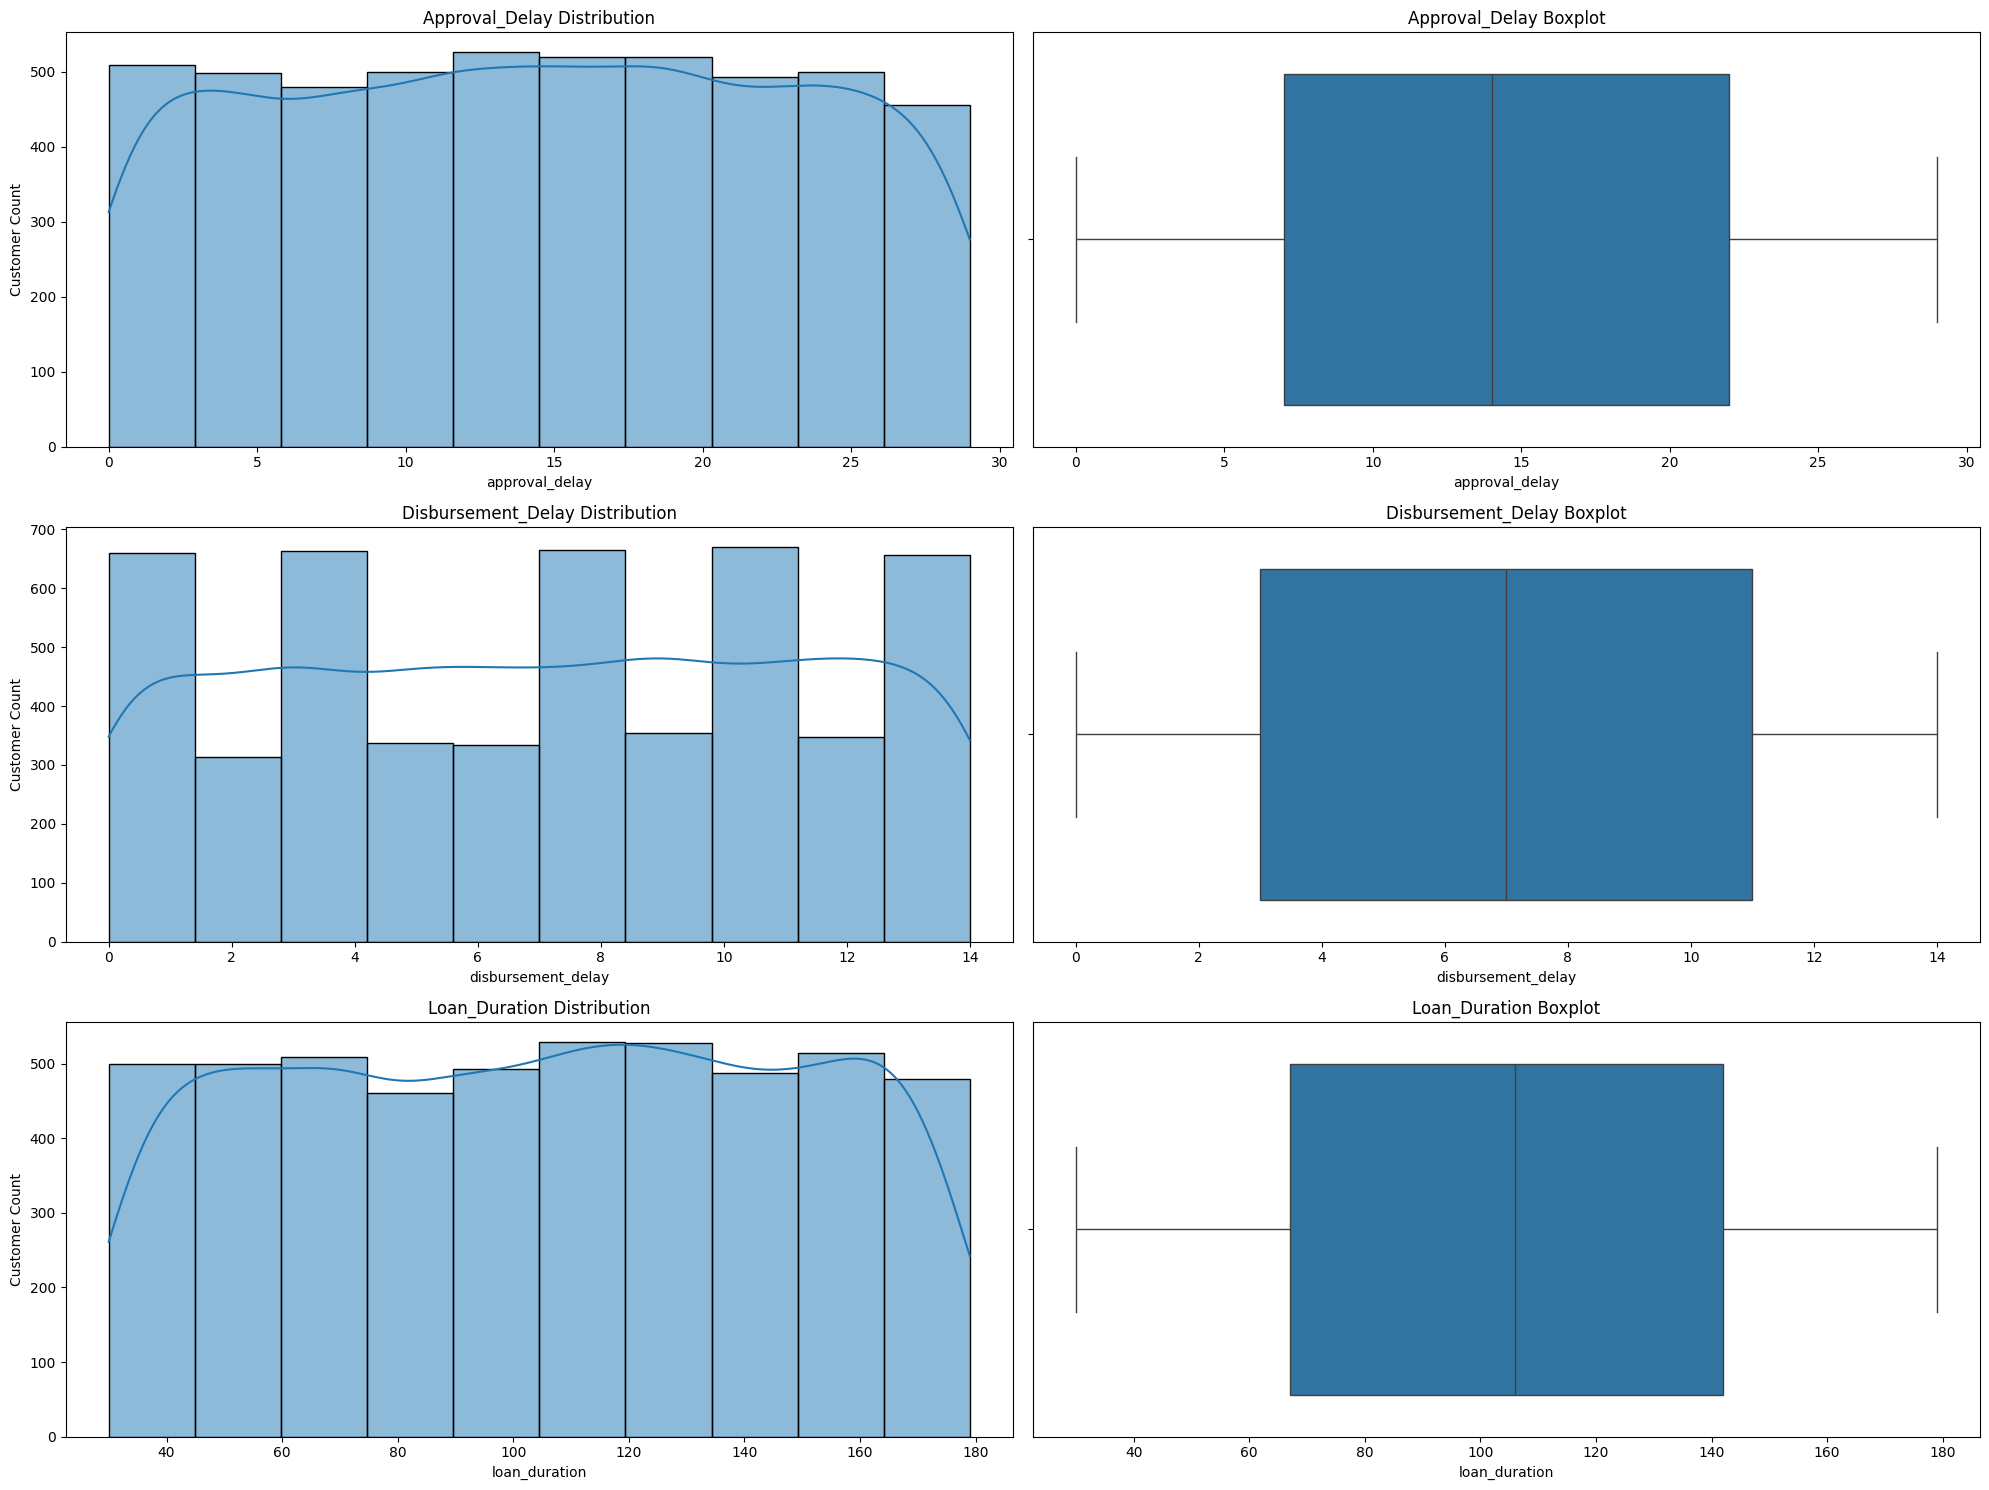

In [5]:
# Explore numeric variables
num_cols = ["approval_delay", "disbursement_delay", "loan_duration"]
n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, bins=10, kde=True, ax=axs[i, 0]).set(
        xlabel=col, ylabel="Customer Count", title=f"{col.title()} Distribution"
    )

    sns.boxplot(data=df, x=col, ax=axs[i, 1]).set(
        xlabel=col, title=f"{col.title()} Boxplot"
    )

plt.tight_layout()

# New Features vs Default Status Distribution

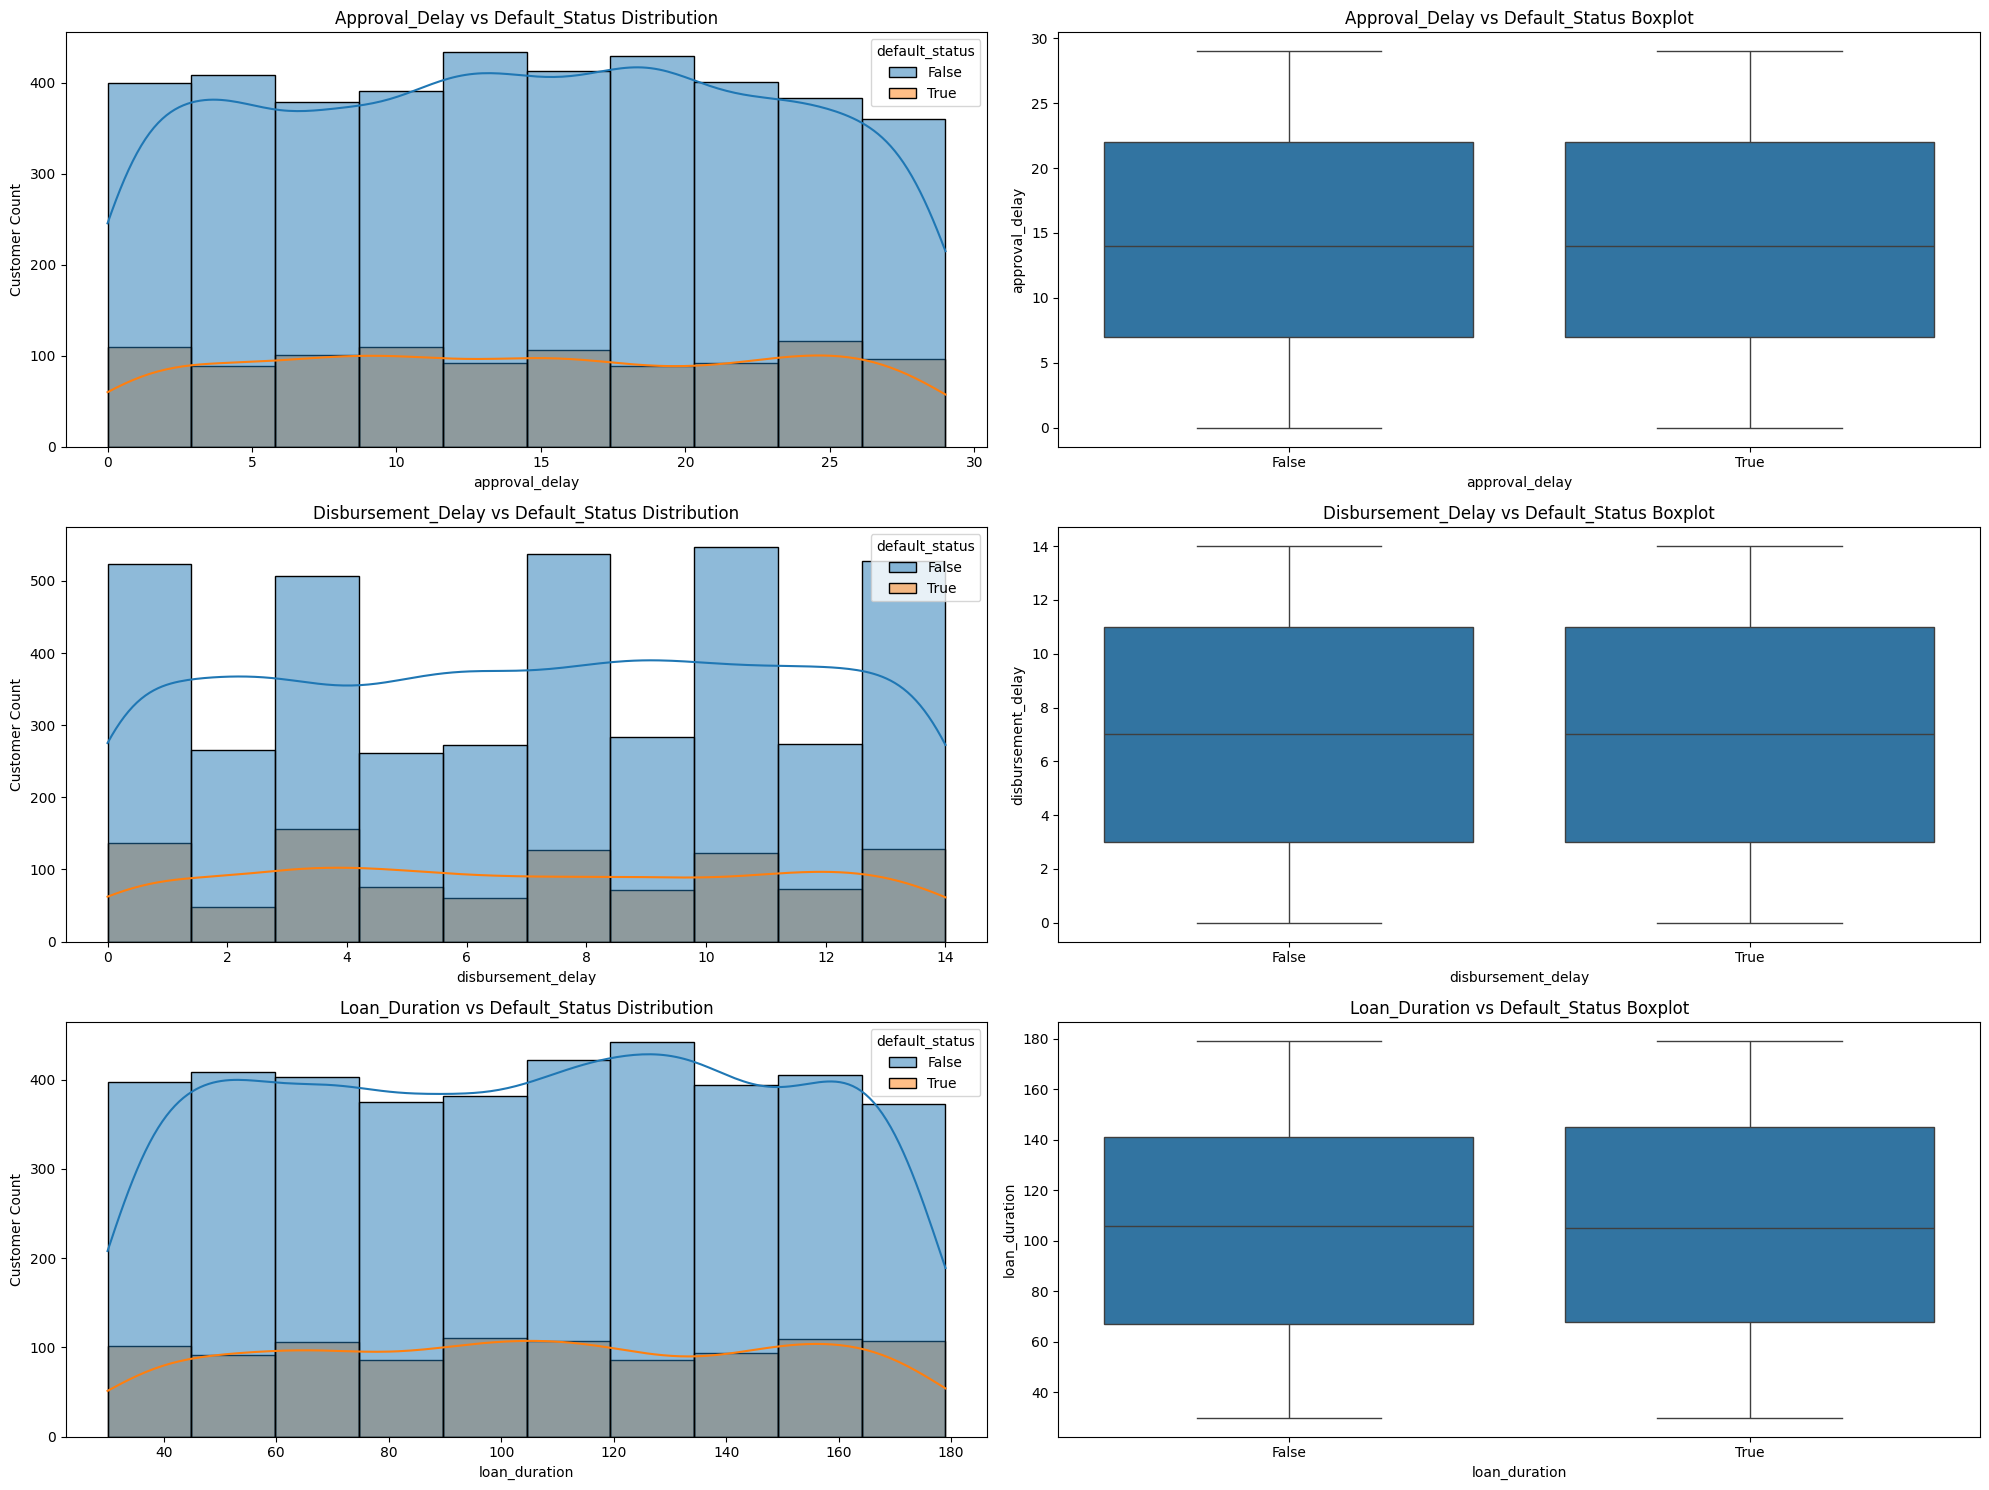

In [6]:
# Explore numeric variables
n_row = len(num_cols)
n_col = 2

fig, axs = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, bins=10, hue="default_status", ax=axs[i, 0]).set(
        xlabel=col, ylabel="Customer Count", title=f"{col.title()} vs Default_Status Distribution"
    )

    sns.boxplot(data=df, x="default_status", y=col, ax=axs[i, 1]).set(
        xlabel=col, title=f"{col.title()} vs Default_Status Boxplot"
    )

plt.tight_layout()

# Feature Selection

### Training a Random Forest Classifier with default parameters and using feature importance to guide feature selection.

In [7]:
X = pd.get_dummies(
    df.drop([
        "customer_id",
        "loan_id",
        "gender",
        "default_status",
        "application_date",
        "approval_date",
        "disbursement_date",
        "due_date"
    ], axis=1),
    drop_first=True,
    dtype="int"
)

y = df["default_status"].astype("int")

In [8]:
rf = RandomForestClassifier(random_state=42)

# fit model
rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


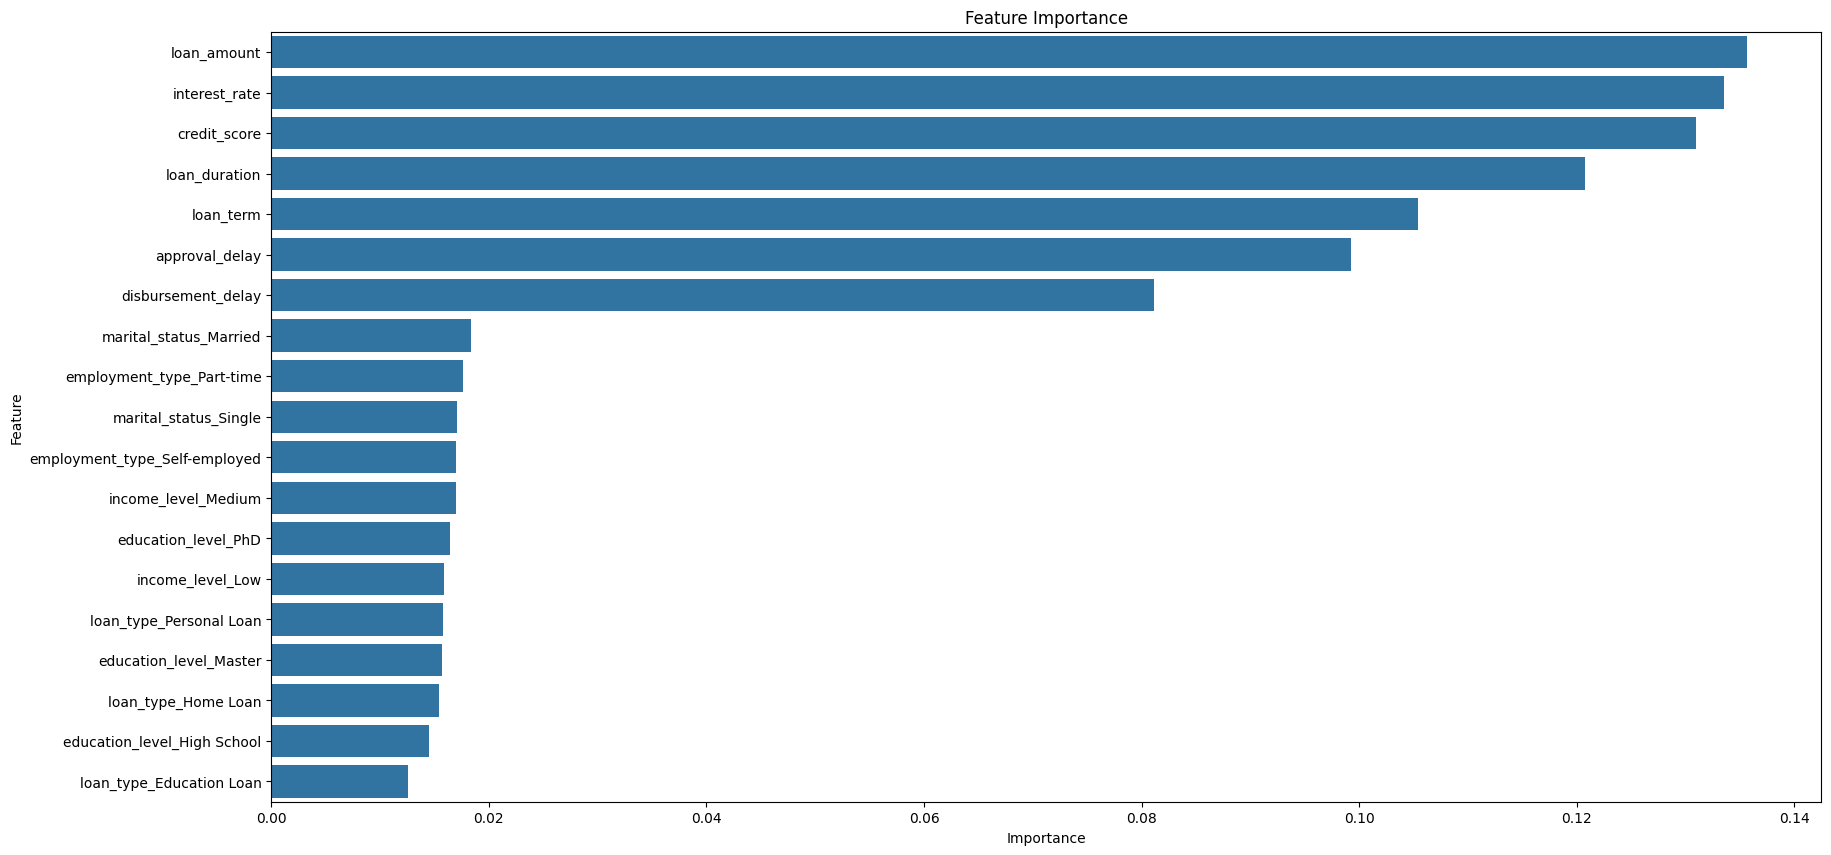

In [9]:
feature_importance = (pd.DataFrame({"Feature":X.columns, "Importance":rf.feature_importances_})
                    .sort_values(by="Importance", ascending=False))

# plot chart of feature importance
plt.figure(figsize=(20, 10))
sns.barplot(data=feature_importance, x="Importance", y="Feature")

plt.title("Feature Importance");

Seems the numeric features do have significant impact on the model, but all one-hot encoded features do have similar impact on the model. In this case, I will use all features for modelling.

In [10]:
df = pd.get_dummies(
        df.drop([
            "customer_id",
            "loan_id",
            "gender",
            "application_date",
            "approval_date",
            "disbursement_date",
            "due_date"
        ], axis=1),
        drop_first=True,
        dtype="int"
)
df["default_status"] = df["default_status"].astype("int")

df

,loan_amount,interest_rate,loan_term,credit_score,default_status,approval_delay,disbursement_delay,loan_duration,loan_type_Education Loan,loan_type_Home Loan,loan_type_Personal Loan,employment_type_Part-time,employment_type_Self-employed,income_level_Low,income_level_Medium,marital_status_Married,marital_status_Single,education_level_High School,education_level_Master,education_level_PhD
0,16795,0.051852,15,833,0,18,1,112,0,0,0,0,1,0,1,0,1,0,1,0
1,1860,0.089296,56,776,0,1,12,83,0,0,1,0,0,0,1,1,0,0,0,0
2,77820,0.070470,51,697,0,3,9,89,0,0,1,0,0,1,0,0,0,1,0,0
3,55886,0.062155,30,795,0,14,3,167,0,0,0,0,0,1,0,1,0,0,0,1
4,7265,0.070635,48,519,0,5,4,109,0,1,0,1,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,37945,0.070087,57,511,0,19,3,119,0,0,0,0,1,0,0,1,0,0,0,1
4996,48937,0.056405,50,502,0,5,10,177,0,0,1,1,0,0,1,0,1,0,0,1
4997,7476,0.064212,58,452,1,15,8,153,0,1,0,0,0,0,0,0,1,1,0,0
4998,52756,0.094914,12,728,0,16,14,154,0,0,0,0,1,0,1,1,0,0,0,1


In [11]:
df.to_csv("../DATA/PREPROCESSED/loan_preprocessed.csv", index=False)